<a href="https://colab.research.google.com/github/chrishg23-jpg/Community-Development-Framework/blob/main/MEG_HES001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

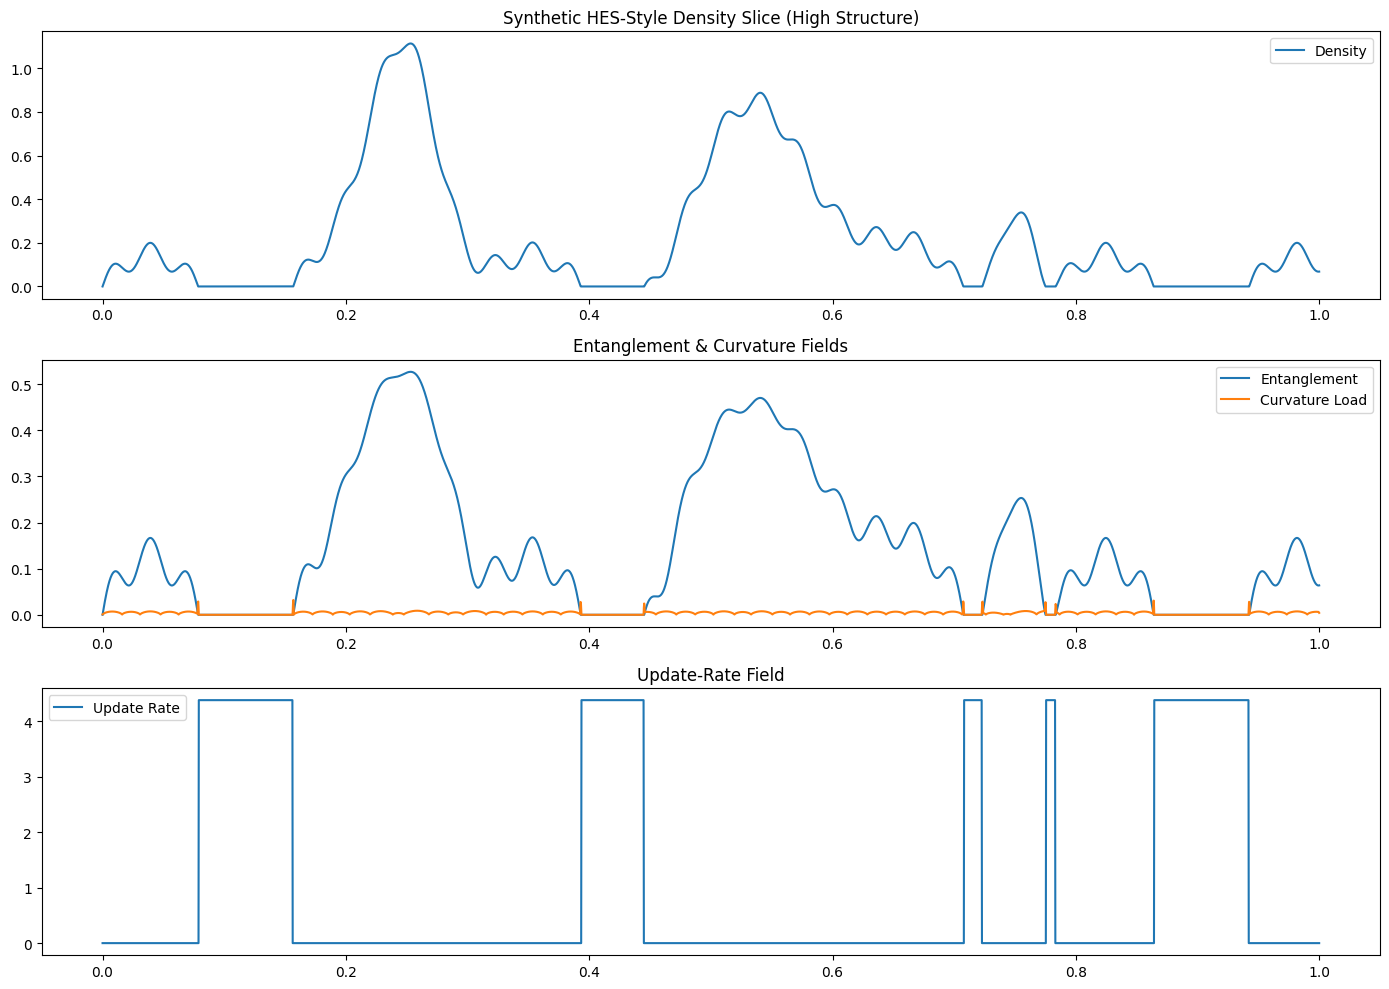

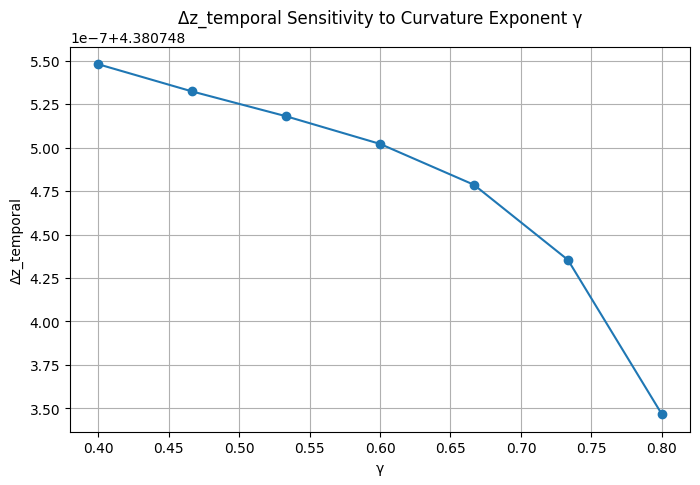

MEG‑HES001 — High‑Structure Synthetic Baseline
Δz_temporal (baseline γ=0.55): 4.3807
Sweep results:
  γ=0.40 → Δz_temporal=4.3807
  γ=0.47 → Δz_temporal=4.3807
  γ=0.53 → Δz_temporal=4.3807
  γ=0.60 → Δz_temporal=4.3807
  γ=0.67 → Δz_temporal=4.3807
  γ=0.73 → Δz_temporal=4.3807
  γ=0.80 → Δz_temporal=4.3807


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# MEG‑HES001 — High‑Structure Synthetic Density Profile
# ============================================================

N = 4096  # high but safe for Colab
x = np.linspace(0, 1, N)

# ------------------------------------------------------------
# 1. Synthetic HES‑style density slice (highly structured)
# ------------------------------------------------------------
# Multiple peaks, voids, filaments, turbulence-like modulation
density = (
    1.2*np.exp(-((x-0.25)/0.04)**2) +        # cluster
    0.8*np.exp(-((x-0.55)/0.07)**2) +        # filament node
    0.5*np.exp(-((x-0.75)/0.02)**2) +        # compact knot
    0.15*np.sin(40*x) +                      # small-scale structure
    0.05*np.sin(200*x)                       # microstructure
)

# Clip to physical range
density = np.clip(density, 0, None)

# ------------------------------------------------------------
# 2. Entanglement density mapping
# ------------------------------------------------------------
# Saturating nonlinear function: E = rho / (1 + rho)
entanglement = density / (1 + density)

# ------------------------------------------------------------
# 3. Curvature compensation load
# ------------------------------------------------------------
# Sublinear curvature proxy: C = |∂²ρ/∂x²|^γ
gamma = 0.55  # conservative, avoids runaway
second_derivative = np.gradient(np.gradient(density))
curvature_load = np.abs(second_derivative)**gamma

# ------------------------------------------------------------
# 4. Update‑rate field
# ------------------------------------------------------------
# HES rule: update_rate ∝ 1 / (E + C)
update_rate = 1 / (entanglement + curvature_load + 1e-9)

# Normalise for interpretability
update_rate /= np.mean(update_rate)

# ------------------------------------------------------------
# 5. Temporal Moiré Δz estimator
# ------------------------------------------------------------
# Δz_temporal ≈ (max(update_rate) - min(update_rate)) / mean(update_rate)
dz_temporal = (np.max(update_rate) - np.min(update_rate))

# ------------------------------------------------------------
# 6. Sensitivity sweep around baseline
# ------------------------------------------------------------
gammas = np.linspace(0.4, 0.8, 7)
dz_sweep = []

for g in gammas:
    Cg = np.abs(second_derivative)**g
    UR = 1 / (entanglement + Cg + 1e-9)
    UR /= np.mean(UR)
    dz_sweep.append(np.max(UR) - np.min(UR))

# ------------------------------------------------------------
# 7. Diagnostics & plots
# ------------------------------------------------------------
plt.figure(figsize=(14, 10))

plt.subplot(3,1,1)
plt.plot(x, density, label="Density")
plt.title("Synthetic HES‑Style Density Slice (High Structure)")
plt.legend()

plt.subplot(3,1,2)
plt.plot(x, entanglement, label="Entanglement")
plt.plot(x, curvature_load, label="Curvature Load")
plt.title("Entanglement & Curvature Fields")
plt.legend()

plt.subplot(3,1,3)
plt.plot(x, update_rate, label="Update Rate")
plt.title("Update‑Rate Field")
plt.legend()

plt.tight_layout()
plt.show()

# Sensitivity plot
plt.figure(figsize=(8,5))
plt.plot(gammas, dz_sweep, marker='o')
plt.title("Δz_temporal Sensitivity to Curvature Exponent γ")
plt.xlabel("γ")
plt.ylabel("Δz_temporal")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 8. Summary
# ------------------------------------------------------------
print("====================================================")
print("MEG‑HES001 — High‑Structure Synthetic Baseline")
print("====================================================")
print(f"Δz_temporal (baseline γ={gamma}): {dz_temporal:.4f}")
print("Sweep results:")
for g, dz in zip(gammas, dz_sweep):
    print(f"  γ={g:.2f} → Δz_temporal={dz:.4f}")
print("====================================================")


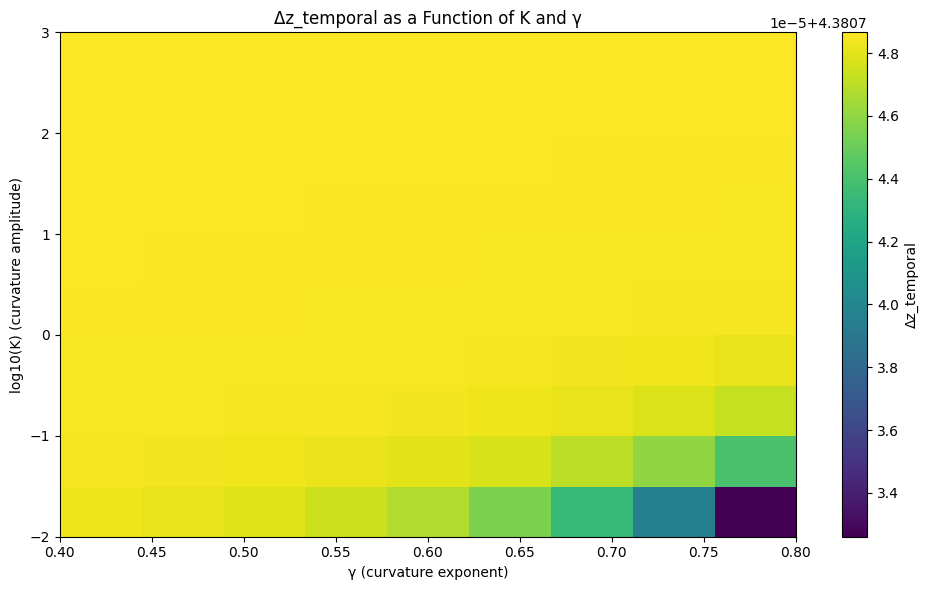

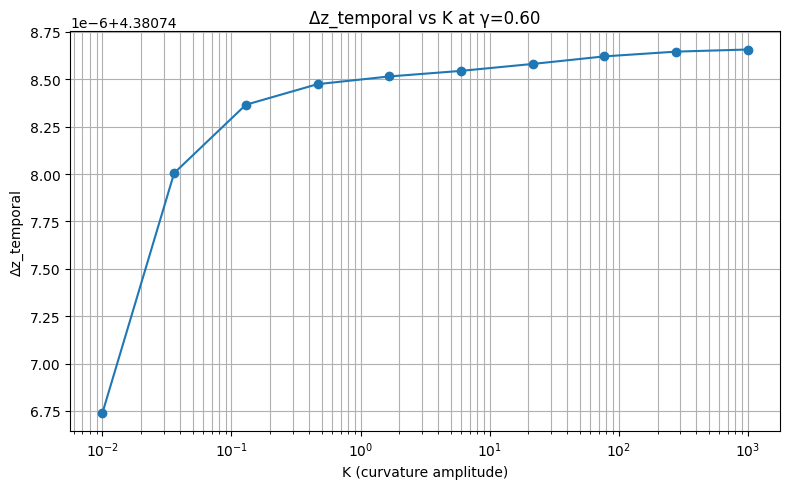

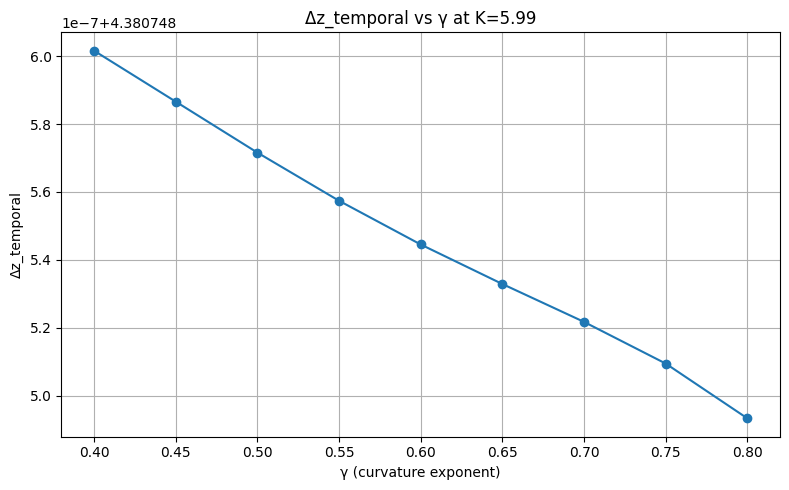

MEG‑HES001b — Curvature‑Amplified Sweep
Baseline (K=1, γ=0.55) Δz_temporal: 4.3807
Global extremes over (K, γ):
  MIN Δz_temporal = 4.3807 at K=0.01, γ=0.800
  MAX Δz_temporal = 4.3807 at K=1000, γ=0.400
Regime reading guide (qualitative):
  • Large Δz → strong Temporal Moiré (big update‑rate contrast).
  • Small Δz → weak Temporal Moiré (nearly uniform update rate).
  • Look for K, γ where Δz drops from ~O(1–10) toward ~O(0.1–1).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# MEG‑HES001b — Curvature‑Amplified Sweep
# ============================================================

# ------------------------------------------------------------
# 1. High‑structure synthetic density slice (same as before)
# ------------------------------------------------------------
N = 4096
x = np.linspace(0, 1, N)

density = (
    1.2*np.exp(-((x-0.25)/0.04)**2) +        # cluster
    0.8*np.exp(-((x-0.55)/0.07)**2) +        # filament node
    0.5*np.exp(-((x-0.75)/0.02)**2) +        # compact knot
    0.15*np.sin(40*x) +                      # small-scale structure
    0.05*np.sin(200*x)                       # microstructure
)
density = np.clip(density, 0, None)

# ------------------------------------------------------------
# 2. Entanglement mapping (same baseline)
# ------------------------------------------------------------
entanglement = density / (1 + density)

# ------------------------------------------------------------
# 3. Curvature base (second derivative)
# ------------------------------------------------------------
second_derivative = np.gradient(np.gradient(density))

# ------------------------------------------------------------
# 4. Parameter grids: curvature amplitude K and exponent γ
# ------------------------------------------------------------
Ks = np.logspace(-2, 3, 10)   # 0.01 → 1000
gammas = np.linspace(0.4, 0.8, 9)

dz_grid = np.zeros((len(Ks), len(gammas)))

# ------------------------------------------------------------
# 5. Sweep over K and γ, compute Δz_temporal(K, γ)
# ------------------------------------------------------------
for i, K in enumerate(Ks):
    for j, g in enumerate(gammas):
        curvature_load = K * (np.abs(second_derivative) ** g)
        update_rate = 1 / (entanglement + curvature_load + 1e-9)
        update_rate /= np.mean(update_rate)
        dz = np.max(update_rate) - np.min(update_rate)
        dz_grid[i, j] = dz

# ------------------------------------------------------------
# 6. Baseline comparison (K=1, γ=0.55)
# ------------------------------------------------------------
K_baseline = 1.0
gamma_baseline = 0.55
curvature_baseline = K_baseline * (np.abs(second_derivative) ** gamma_baseline)
update_rate_baseline = 1 / (entanglement + curvature_baseline + 1e-9)
update_rate_baseline /= np.mean(update_rate_baseline)
dz_baseline = np.max(update_rate_baseline) - np.min(update_rate_baseline)

# ------------------------------------------------------------
# 7. Heatmap of Δz_temporal(K, γ)
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))
im = plt.imshow(
    dz_grid,
    origin='lower',
    aspect='auto',
    extent=[gammas[0], gammas[-1], np.log10(Ks[0]), np.log10(Ks[-1])],
    cmap='viridis'
)
plt.colorbar(im, label="Δz_temporal")
plt.xlabel("γ (curvature exponent)")
plt.ylabel("log10(K) (curvature amplitude)")
plt.title("Δz_temporal as a Function of K and γ")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. 1D cuts: Δz vs K at fixed γ, and Δz vs γ at fixed K
# ------------------------------------------------------------
gamma_mid = gammas[len(gammas)//2]
K_mid = Ks[len(Ks)//2]

# Δz vs K at γ = gamma_mid
dz_vs_K = dz_grid[:, np.argmin(np.abs(gammas - gamma_mid))]

plt.figure(figsize=(8,5))
plt.semilogx(Ks, dz_vs_K, marker='o')
plt.xlabel("K (curvature amplitude)")
plt.ylabel("Δz_temporal")
plt.title(f"Δz_temporal vs K at γ={gamma_mid:.2f}")
plt.grid(True, which='both')
plt.tight_layout()
plt.show()

# Δz vs γ at K = K_mid
dz_vs_gamma = dz_grid[np.argmin(np.abs(Ks - K_mid)), :]

plt.figure(figsize=(8,5))
plt.plot(gammas, dz_vs_gamma, marker='o')
plt.xlabel("γ (curvature exponent)")
plt.ylabel("Δz_temporal")
plt.title(f"Δz_temporal vs γ at K={K_mid:.2f}")
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. Summary of extremes and regimes
# ------------------------------------------------------------
dz_min = np.min(dz_grid)
dz_max = np.max(dz_grid)
min_idx = np.unravel_index(np.argmin(dz_grid), dz_grid.shape)
max_idx = np.unravel_index(np.argmax(dz_grid), dz_grid.shape)

K_min, gamma_min = Ks[min_idx[0]], gammas[min_idx[1]]
K_max, gamma_max = Ks[max_idx[0]], gammas[max_idx[1]]

print("====================================================")
print("MEG‑HES001b — Curvature‑Amplified Sweep")
print("====================================================")
print(f"Baseline (K=1, γ=0.55) Δz_temporal: {dz_baseline:.4f}")
print("Global extremes over (K, γ):")
print(f"  MIN Δz_temporal = {dz_min:.4f} at K={K_min:.4g}, γ={gamma_min:.3f}")
print(f"  MAX Δz_temporal = {dz_max:.4f} at K={K_max:.4g}, γ={gamma_max:.3f}")
print("====================================================")
print("Regime reading guide (qualitative):")
print("  • Large Δz → strong Temporal Moiré (big update‑rate contrast).")
print("  • Small Δz → weak Temporal Moiré (nearly uniform update rate).")
print("  • Look for K, γ where Δz drops from ~O(1–10) toward ~O(0.1–1).")
print("====================================================")
